In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose


R provides numerous datasets that are accessible through Python

In [3]:
from statsmodels.datasets import get_rdataset

# Access R datasets
ausbeer = get_rdataset('ausbeer', 'fpp2').data


In [7]:
df = pd.read_csv("AUS_monthly_beer_production.csv")
df

,time,value
0,1956.00,284
1,1956.25,213
2,1956.50,227
3,1956.75,308
4,1957.00,262
...,...,...
213,2009.25,398
214,2009.50,419
215,2009.75,488
216,2010.00,414


# Seasonal decomposition

<Figure size 2600x1400 with 0 Axes>

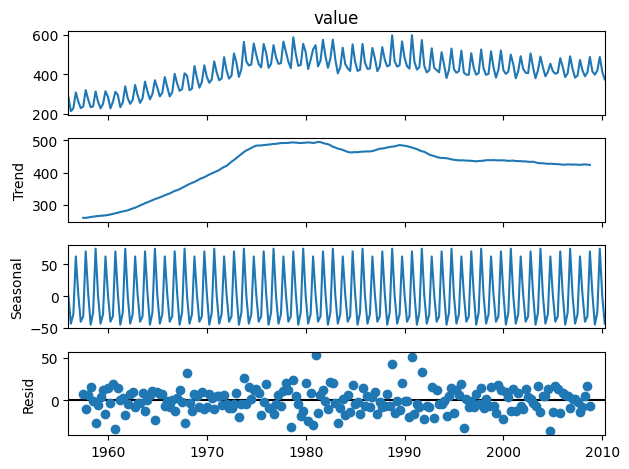

In [10]:
plt.figure(figsize=(26,14))
# set index to "time"
df_indexed = df.set_index("time")
df_indexed
# call decomposition model (seasonal_decompose)
decomposition = seasonal_decompose(df_indexed['value'], model='additive', period=12)

# plot the decomposition
decomposition.plot()
plt.show()

# autocorrelation raw data

The data are quaterly (4 observations per year). So for a good analysis:
16 (4quarters * 4 years) or 20 lags (4quarters * 5 years)  
Important is to not exceed: 218/4

If nlags is not specified in the acf --> the standard n=24

In [12]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# calculate autocorrelation
lag_acf = acf(df_indexed['value'], nlags=20)
lag_pacf = pacf(df_indexed['value'], nlags=20, method='ols')

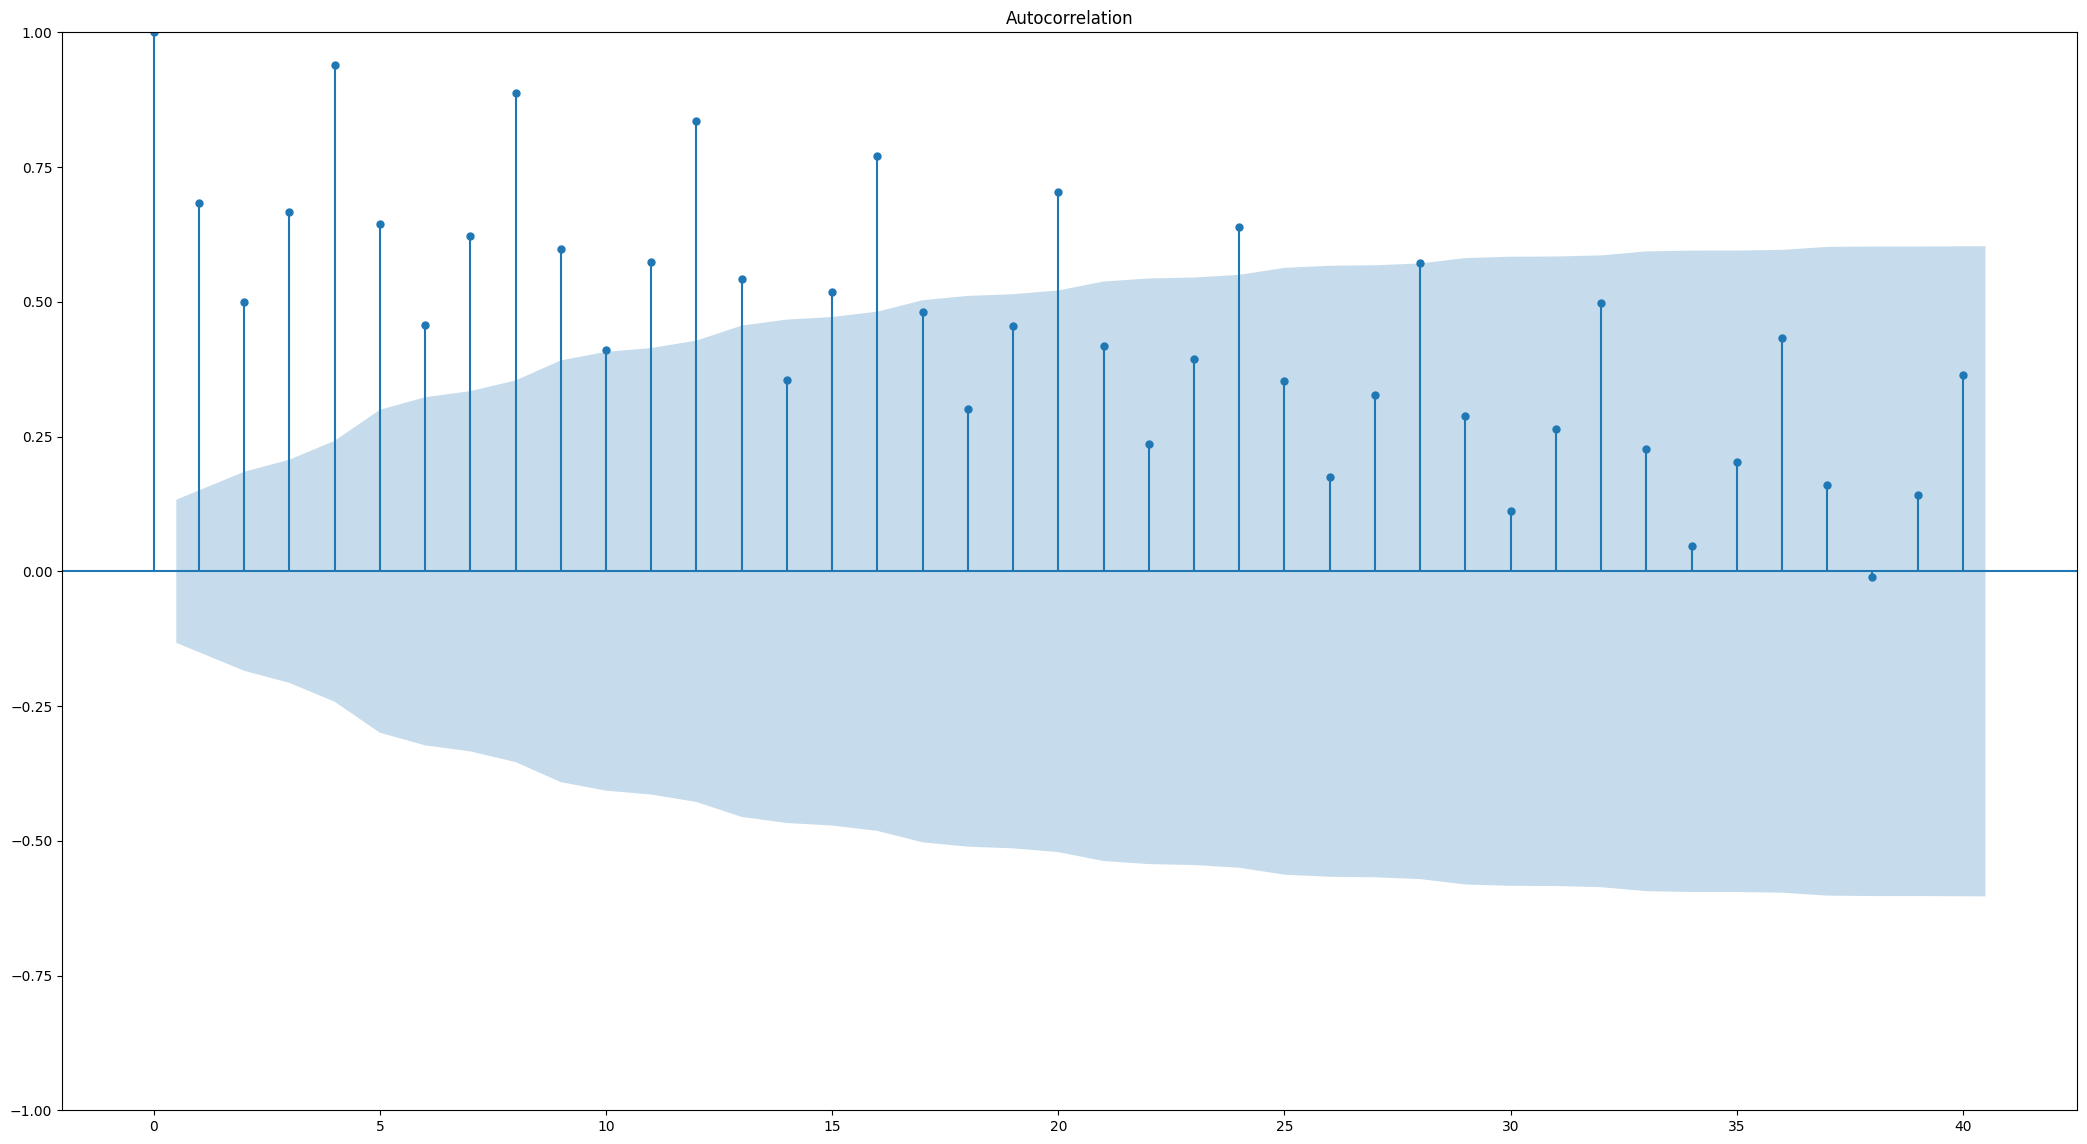

In [14]:
# plot acf, changing the number of lags
plt.figure(figsize=(26,14))
plot_acf(df_indexed['value'], lags=40, ax=plt.gca())
plt.show()

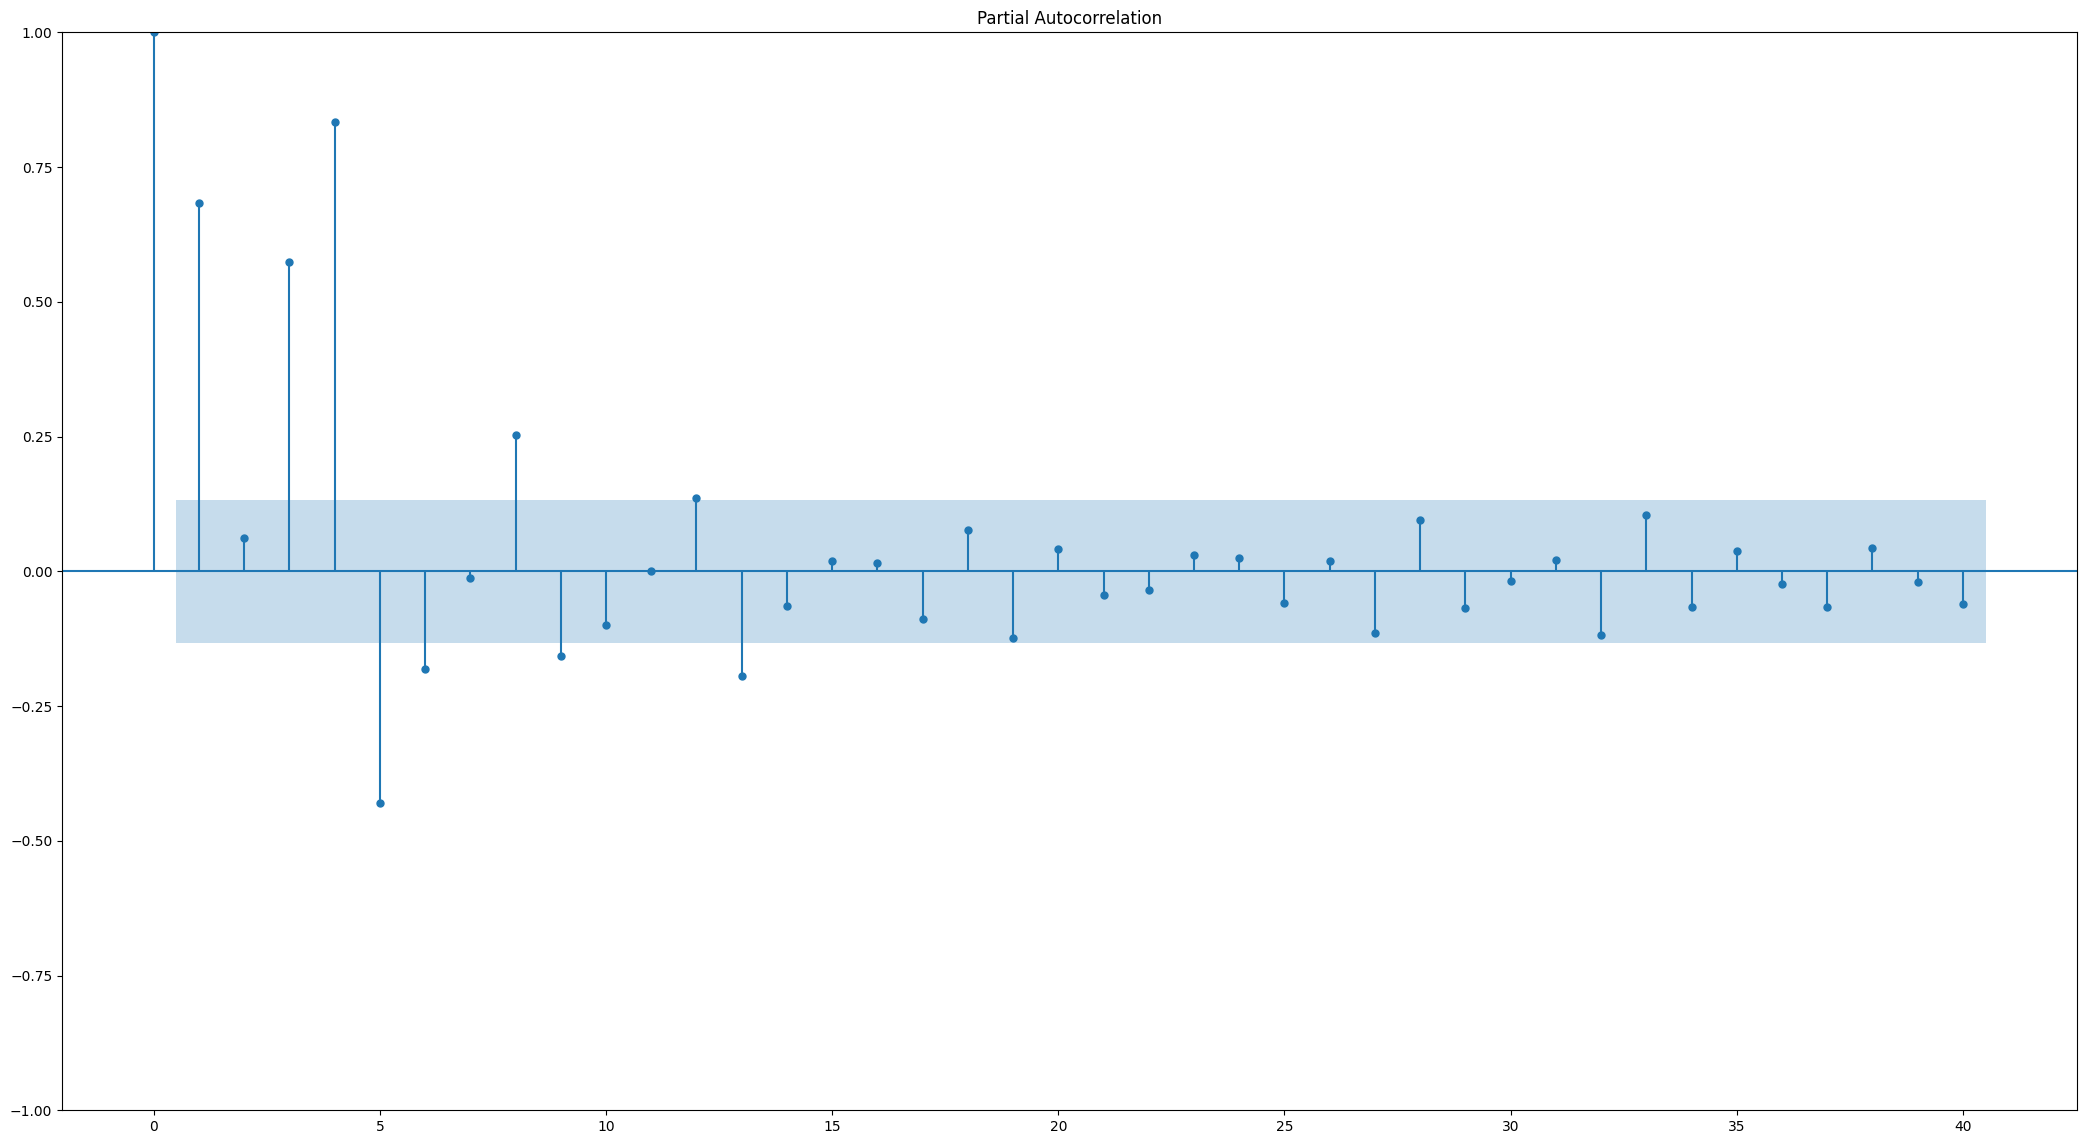

In [15]:
# plot pacf
plt.figure(figsize=(26,14))
plot_pacf(df_indexed['value'], lags=40, ax=plt.gca())
plt.show()

# correlation stationary data

## check stationarity

We checked viually that it has seasonality and trend, but check it in code either way as well.

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss

# test to check if the data are stationary
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'{name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.6f}')
    print(f'  Stationary: {result[1] < 0.05}\n')

In [17]:
# Original series
y_beer = df['value']

# Step 1: Quaterly differencing (four times for quarterly data)
y_seasonal_diff = y_beer.diff(4).dropna()

# Step 2: First differencing (if needed after seasonal diff)
y_stationary_beer = y_seasonal_diff.diff(1).dropna()

# Check stationarity at each step
check_stationarity(y_beer, 'Original')
check_stationarity(y_seasonal_diff, 'After seasonal diff (lag=4)')
check_stationarity(y_stationary_beer, 'After seasonal + first diff')

Original:
  ADF Statistic: -2.6113
  p-value: 0.090677
  Stationary: False

After seasonal diff (lag=4):
  ADF Statistic: -2.0197
  p-value: 0.278018
  Stationary: False

After seasonal + first diff:
  ADF Statistic: -7.3529
  p-value: 0.000000
  Stationary: True



## acf and pacf

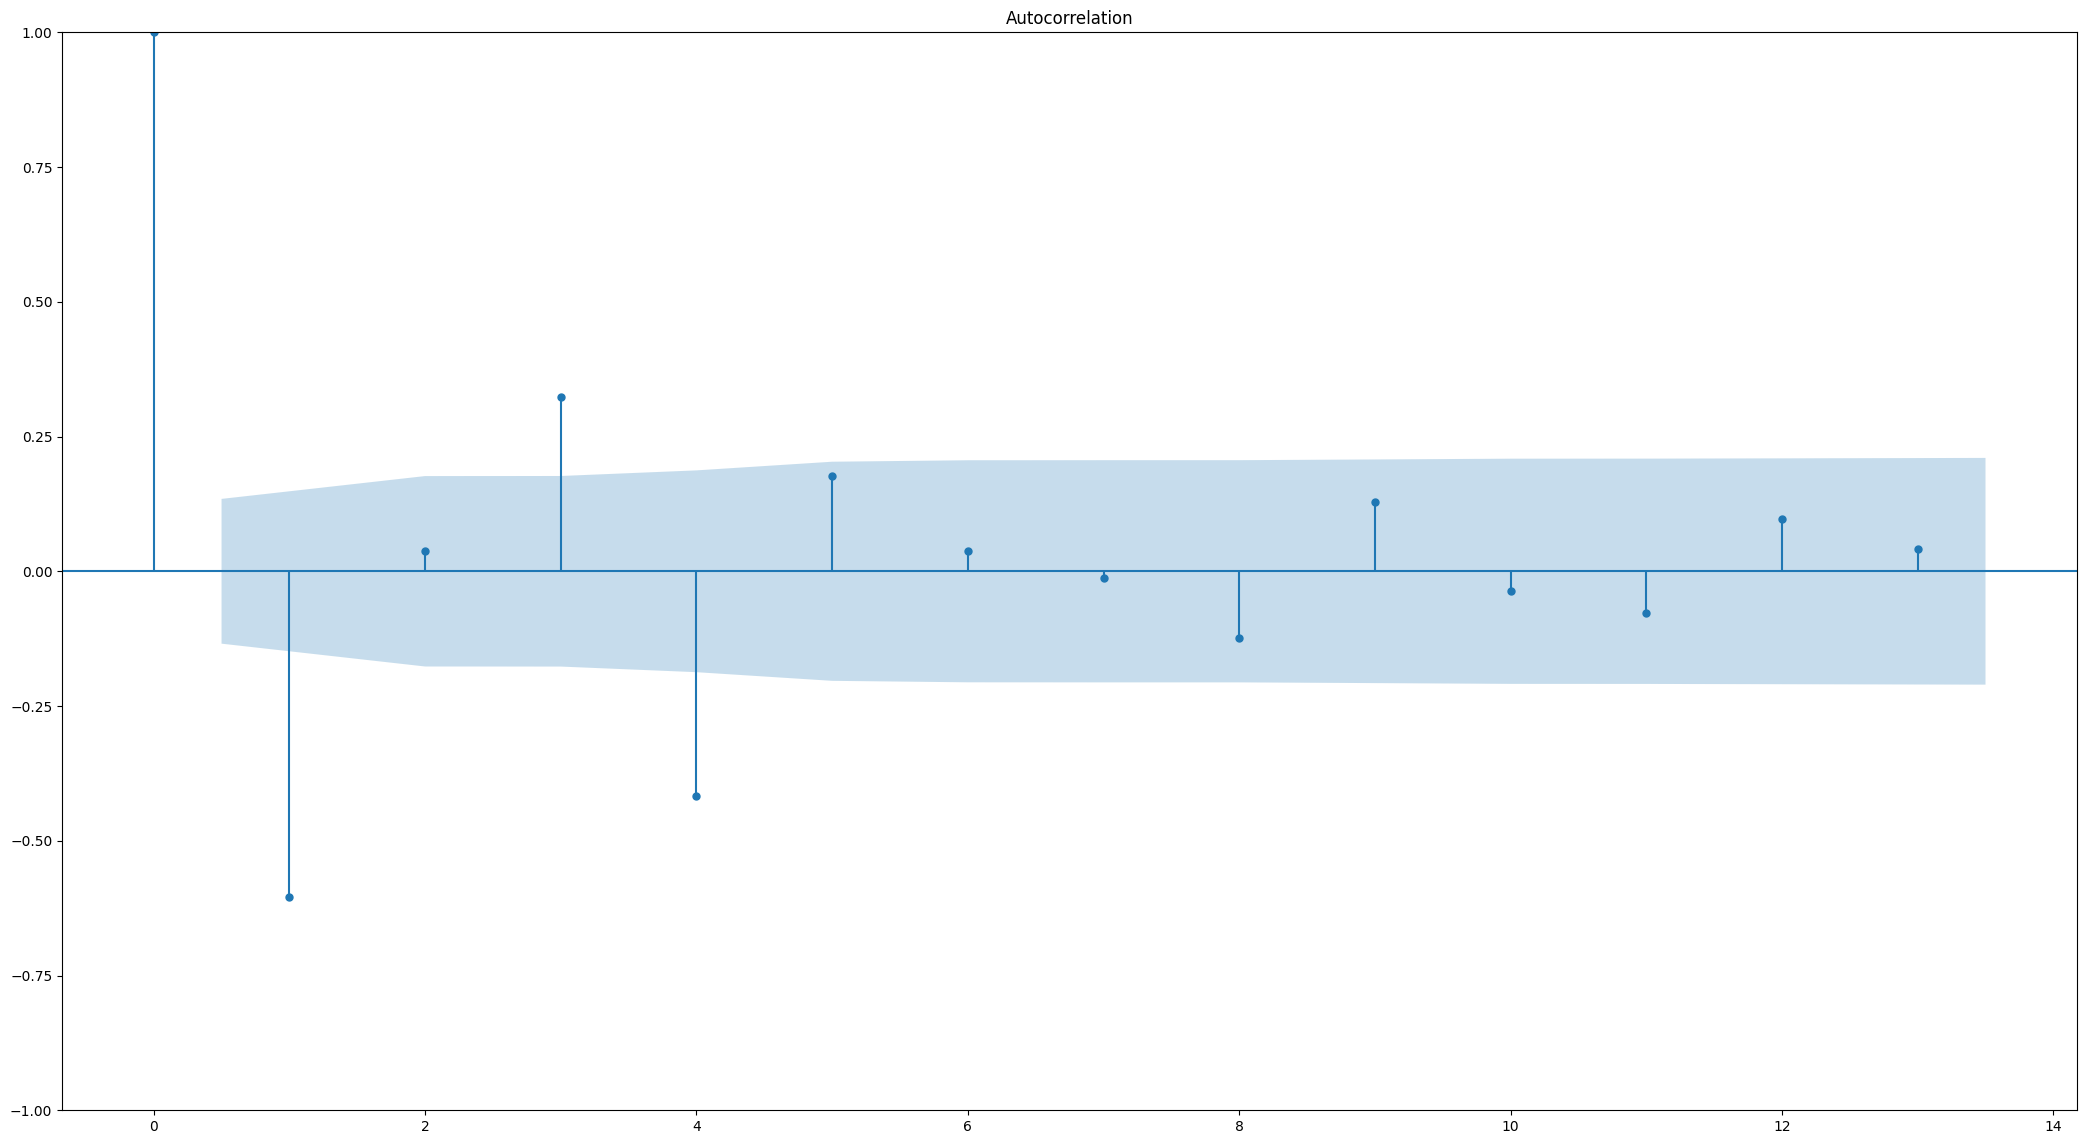

In [23]:
# plot acf
plt.figure(figsize=(26,14))
plot_acf(y_stationary_beer, lags=13, ax=plt.gca())
plt.show()

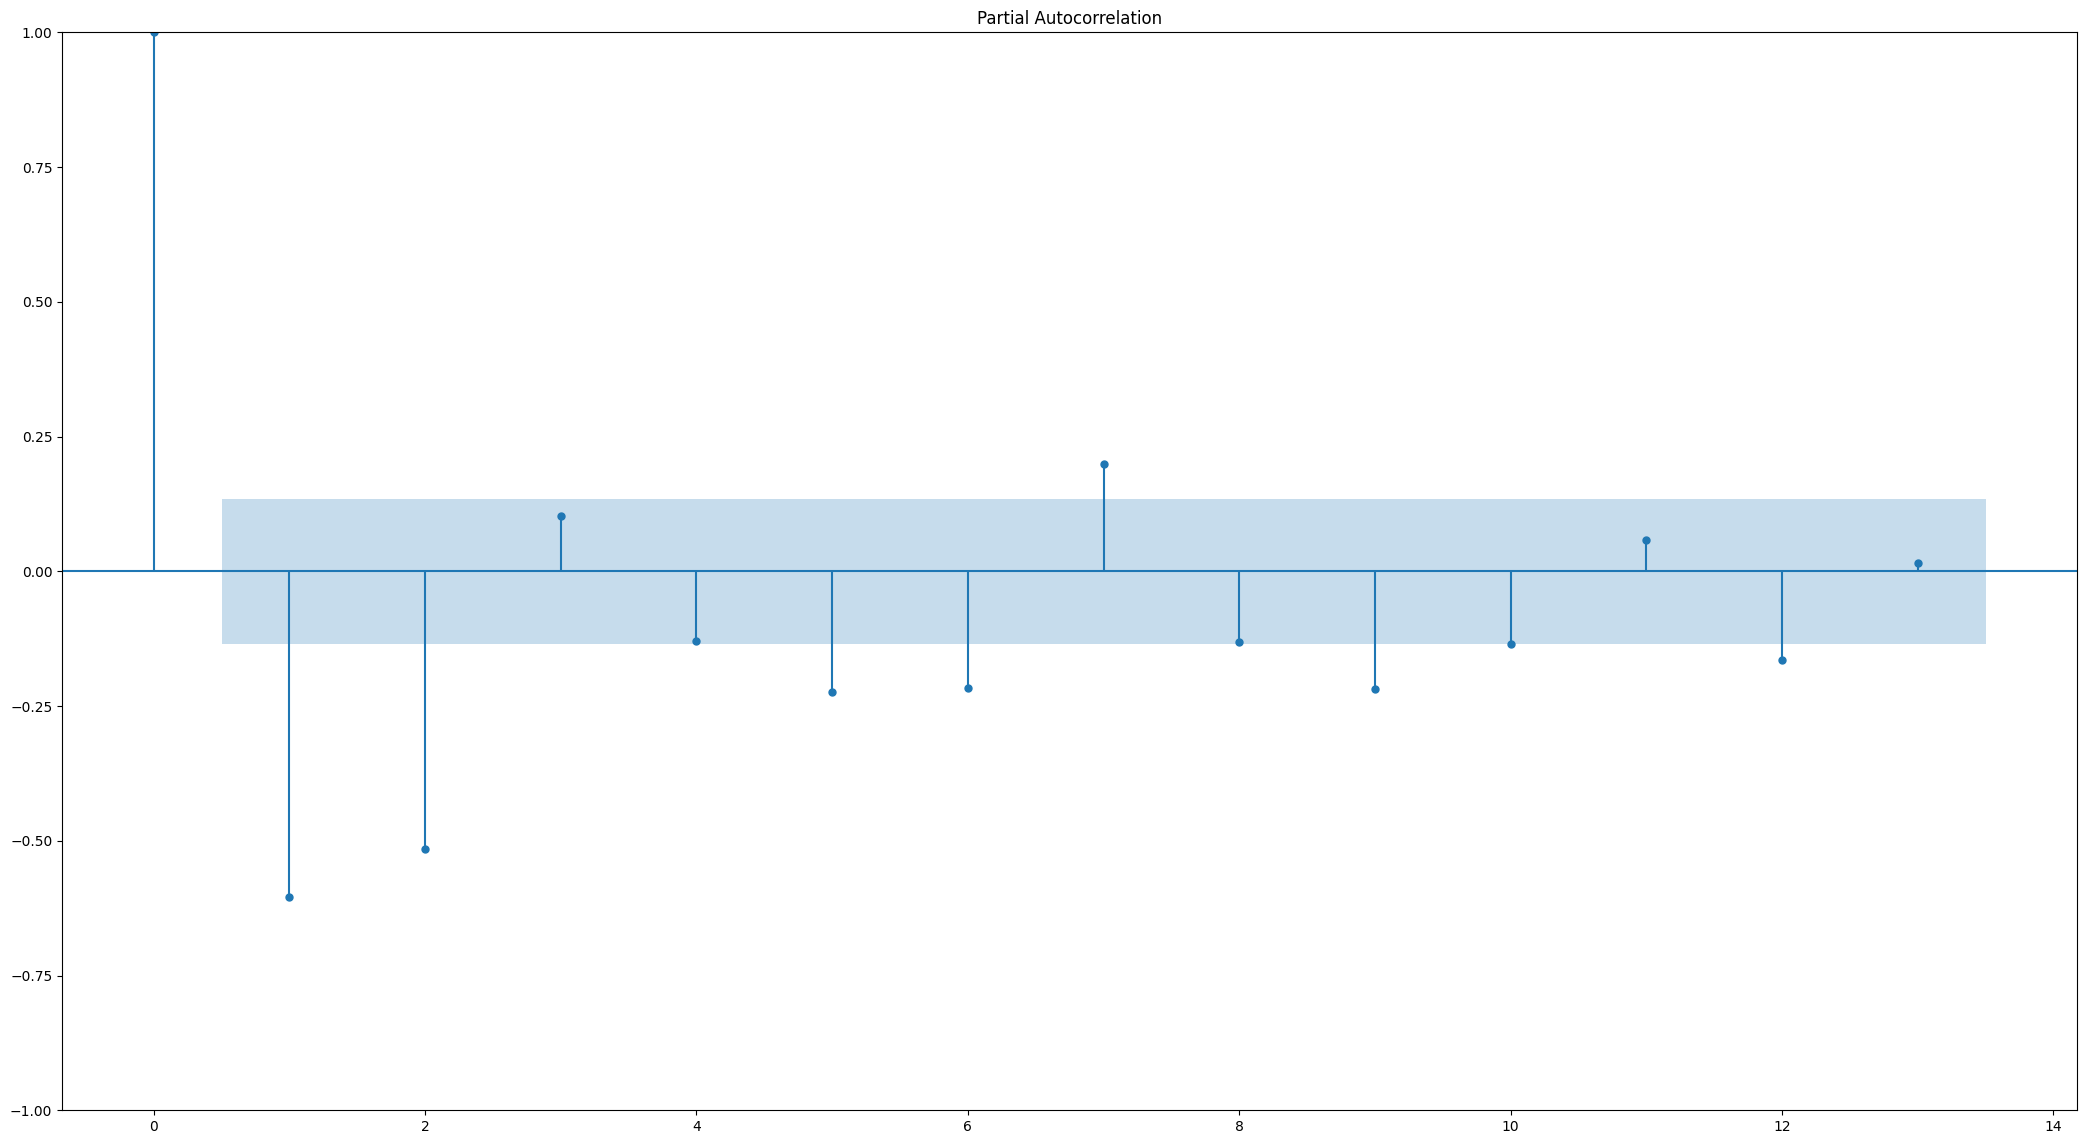

In [22]:
# plot pacf
plt.figure(figsize=(26,14))
plot_pacf(y_stationary_beer, lags=13, ax=plt.gca())
plt.show()